# Regional Sales Analysis & Prediction


## 1. Import Libraries

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Time Series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Load Cleaned Data

In [ ]:
# Load cleaned datasets
df = pd.read_csv('cleaned_sales_data.csv')
df_monthly = pd.read_csv('monthly_aggregated_data.csv')
df_products = pd.read_csv('product_performance.csv')
df_regions = pd.read_csv('regional_performance.csv')

# Convert date columns
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df_monthly['Year-Month'] = pd.to_datetime(df_monthly['Year-Month'])

print("✓ Data loaded successfully!")
print(f"\nMain dataset: {df.shape}")
print(f"Monthly data: {df_monthly.shape}")
print(f"Product data: {df_products.shape}")
print(f"Regional data: {df_regions.shape}")

✓ Data loaded successfully!

Main dataset: (64068, 19)
Monthly data: (51, 7)
Product data: (30, 6)
Regional data: (47, 5)


## 3. Key Performance Metrics

In [ ]:
# Calculate key metrics
total_revenue = df['Line Total'].sum()
total_profit = df['Profit'].sum()
avg_profit_margin = df['Profit Margin %'].mean()
total_orders = df['OrderNumber'].nunique()
avg_order_value = total_revenue / total_orders

print("\n" + "="*70)
print("OVERALL PERFORMANCE METRICS (2021-2024)")
print("="*70)
print(f"Total Revenue:        ${total_revenue:,.2f}")
print(f"Total Profit:         ${total_profit:,.2f}")
print(f"Avg Profit Margin:    {avg_profit_margin:.2f}%")
print(f"Total Orders:         {total_orders:,}")
print(f"Average Order Value:  ${avg_order_value:,.2f}")
print("="*70)


OVERALL PERFORMANCE METRICS (2021-2024)
Total Revenue:        $1,235,313,947.20
Total Profit:         $1,143,561,443.21
Avg Profit Margin:    91.96%
Total Orders:         10,684
Average Order Value:  $115,622.80


## 4. Interactive Visualizations (Plotly)

### 4.1 Revenue & Profit Trends

In [ ]:
# Interactive line chart for revenue and profit trends
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Monthly Revenue Trend', 'Monthly Profit Trend'),
    vertical_spacing=0.12
)

# Revenue
fig.add_trace(
    go.Scatter(x=df_monthly['Year-Month'], y=df_monthly['Revenue'],
               mode='lines+markers', name='Revenue',
               line=dict(color='#1f77b4', width=3)),
    row=1, col=1
)

# Profit
fig.add_trace(
    go.Scatter(x=df_monthly['Year-Month'], y=df_monthly['Profit'],
               mode='lines+markers', name='Profit',
               line=dict(color='#2ca02c', width=3)),
    row=2, col=1
)

fig.update_xaxes(title_text="Date", row=2, col=1)
fig.update_yaxes(title_text="Revenue ($)", row=1, col=1)
fig.update_yaxes(title_text="Profit ($)", row=2, col=1)

fig.update_layout(height=700, showlegend=False, title_text="Sales Performance Over Time")
fig.show()

### 4.2 Top Products & Regions

In [ ]:
# Top 10 Products
fig = px.bar(df_products.head(10), 
             x='Revenue', y='Product',
             orientation='h',
             title='Top 10 Products by Revenue',
             labels={'Revenue': 'Revenue ($)', 'Product': 'Product'},
             color='Profit',
             color_continuous_scale='Viridis')
fig.update_layout(height=500)
fig.show()

# Top 10 States
fig = px.bar(df_regions.head(10), 
             x='Revenue', y='State',
             orientation='h',
             title='Top 10 States by Revenue',
             labels={'Revenue': 'Revenue ($)', 'State': 'State'},
             color='Profit',
             color_continuous_scale='Blues')
fig.update_layout(height=500)
fig.show()

### 4.3 Seasonal Patterns

In [ ]:
# Monthly pattern
monthly_pattern = df.groupby('Month').agg({
    'Line Total': 'sum',
    'Profit': 'sum'
}).reset_index()

fig = go.Figure()
fig.add_trace(go.Bar(x=monthly_pattern['Month'], y=monthly_pattern['Line Total'],
                     name='Revenue', marker_color='steelblue'))
fig.add_trace(go.Bar(x=monthly_pattern['Month'], y=monthly_pattern['Profit'],
                     name='Profit', marker_color='seagreen'))

fig.update_layout(
    title='Seasonal Pattern - Revenue & Profit by Month',
    xaxis_title='Month',
    yaxis_title='Amount ($)',
    barmode='group',
    height=500
)
fig.show()

### 4.4 Time Series Decomposition

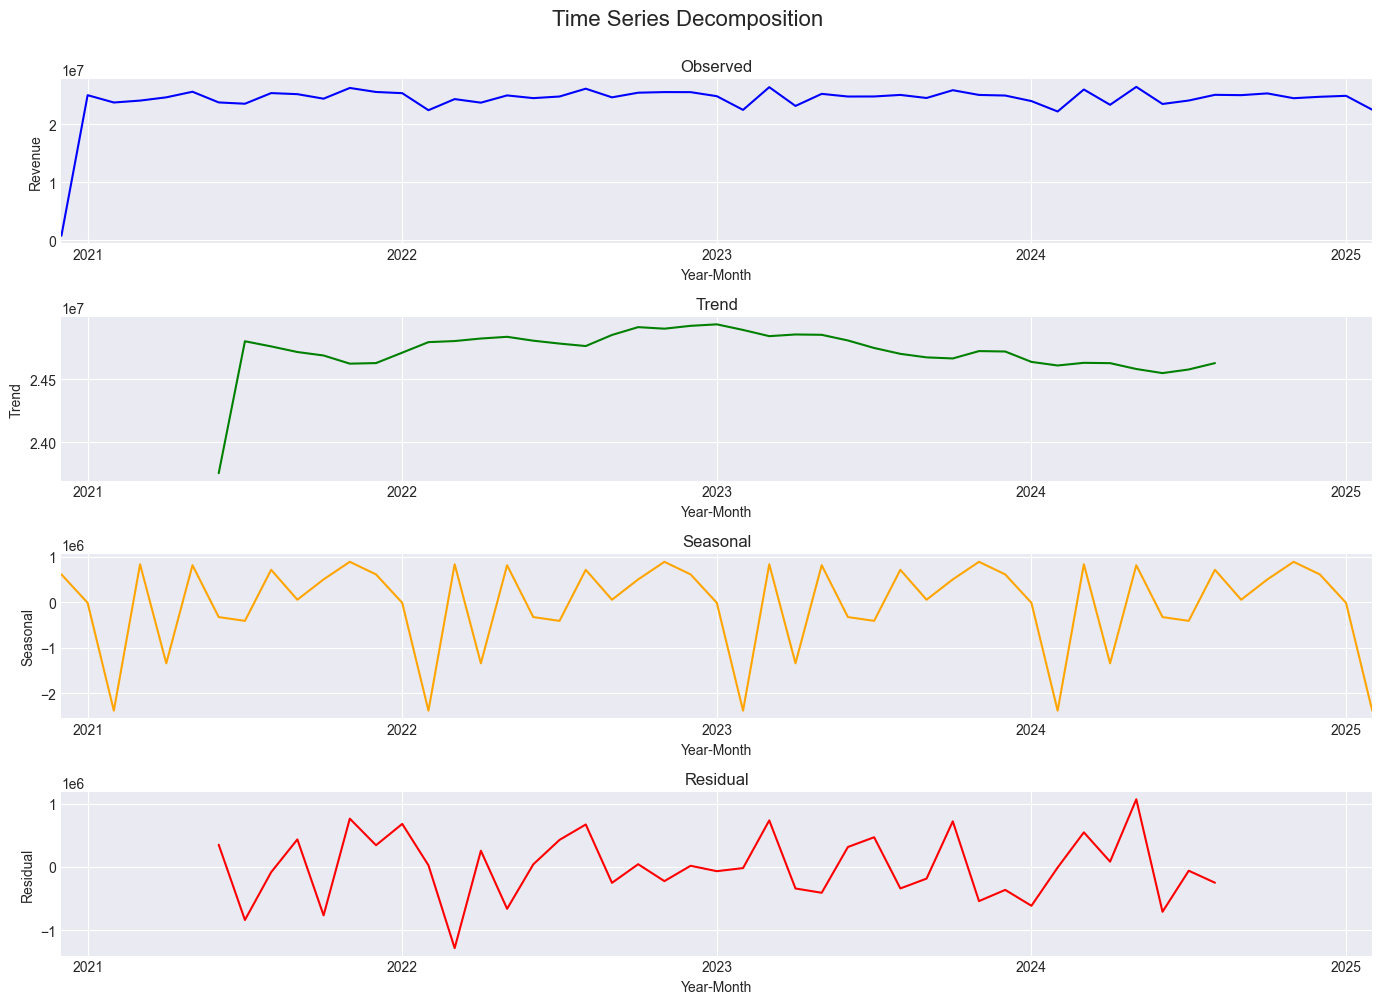

In [ ]:
# Prepare time series
ts_data = df_monthly.set_index('Year-Month')['Revenue']

# Decompose
decomposition = seasonal_decompose(ts_data, model='additive', period=12)

# Plot using matplotlib (inline display only)
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomposition.observed.plot(ax=axes[0], title='Observed', color='blue')
axes[0].set_ylabel('Revenue')

decomposition.trend.plot(ax=axes[1], title='Trend', color='green')
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2], title='Seasonal', color='orange')
axes[2].set_ylabel('Seasonal')

decomposition.resid.plot(ax=axes[3], title='Residual', color='red')
axes[3].set_ylabel('Residual')

plt.suptitle('Time Series Decomposition', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

## 5. Machine Learning - Revenue Prediction

### 5.1 Prepare Data

In [ ]:
# Create features for ML
df_ml = df.copy()

# Encode categorical variables
le_channel = LabelEncoder()
if 'Channel' in df_ml.columns:
    df_ml['Channel_Encoded'] = le_channel.fit_transform(df_ml['Channel'])

# Select features
feature_cols = ['Year', 'Month', 'Quarter', 'Order Quantity', 'Unit Price']
if 'Channel_Encoded' in df_ml.columns:
    feature_cols.append('Channel_Encoded')

# Remove missing values
df_ml = df_ml.dropna(subset=feature_cols + ['Line Total'])

X = df_ml[feature_cols]
y = df_ml['Line Total']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✓ Data prepared for ML")
print(f"Features: {feature_cols}")
print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")

✓ Data prepared for ML
Features: ['Year', 'Month', 'Quarter', 'Order Quantity', 'Unit Price', 'Channel_Encoded']
Training set: 51,254 samples
Test set: 12,814 samples


### 5.2 Train Multiple Models

In [ ]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

# Train and evaluate all models
results = {}

print("\n" + "="*80)
print("TRAINING MODELS...")
print("="*80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred_test)
    mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100
    
    # Train metrics
    r2_train = r2_score(y_train, y_pred_train)
    
    results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape,
        'R2_Train': r2_train,
        'predictions': y_pred_test,
        'model': model
    }
    
    print(f"  MAE:   ${mae:,.2f}")
    print(f"  RMSE:  ${rmse:,.2f}")
    print(f"  R²:    {r2:.4f}")
    print(f"  MAPE:  {mape:.2f}%")

print("\n" + "="*80)
print("✓ All models trained successfully!")
print("="*80)


TRAINING MODELS...

Training Linear Regression...
  MAE:   $2,725.55
  RMSE:  $3,793.07
  R²:    0.9394
  MAPE:  43.42%

Training Ridge Regression...
  MAE:   $2,725.55
  RMSE:  $3,793.07
  R²:    0.9394
  MAPE:  43.42%

Training Lasso Regression...
  MAE:   $2,725.50
  RMSE:  $3,793.10
  R²:    0.9394
  MAPE:  43.41%

Training Decision Tree...
  MAE:   $60.75
  RMSE:  $82.69
  R²:    1.0000
  MAPE:  0.46%

Training Random Forest...
  MAE:   $0.60
  RMSE:  $5.68
  R²:    1.0000
  MAPE:  0.00%

Training Gradient Boosting...
  MAE:   $84.11
  RMSE:  $133.74
  R²:    0.9999
  MAPE:  0.61%

✓ All models trained successfully!


### 5.3 Model Comparison

In [ ]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': [results[m]['MAE'] for m in results.keys()],
    'MSE': [results[m]['MSE'] for m in results.keys()],
    'RMSE': [results[m]['RMSE'] for m in results.keys()],
    'R² Score': [results[m]['R2'] for m in results.keys()],
    'MAPE (%)': [results[m]['MAPE'] for m in results.keys()],
    'R² Train': [results[m]['R2_Train'] for m in results.keys()]
})

# Sort by R² Score
comparison_df = comparison_df.sort_values('R² Score', ascending=False)

print("\nMODEL PERFORMANCE COMPARISON:")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Find best model
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   R² Score: {comparison_df.iloc[0]['R² Score']:.4f}")
print(f"   RMSE: ${comparison_df.iloc[0]['RMSE']:,.2f}")


MODEL PERFORMANCE COMPARISON:
            Model     MAE         MSE    RMSE  R² Score  MAPE (%)  R² Train
    Random Forest    0.60       32.21    5.68      1.00      0.00      1.00
    Decision Tree   60.75     6837.56   82.69      1.00      0.46      1.00
Gradient Boosting   84.11    17886.18  133.74      1.00      0.61      1.00
Linear Regression 2725.55 14387407.97 3793.07      0.94     43.42      0.94
 Ridge Regression 2725.55 14387409.16 3793.07      0.94     43.42      0.94
 Lasso Regression 2725.50 14387571.06 3793.10      0.94     43.41      0.94

🏆 Best Model: Random Forest
   R² Score: 1.0000
   RMSE: $5.68


### 5.4 Visualize Model Performance

In [ ]:
# Interactive comparison charts
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('R² Score', 'RMSE ($)', 'MAE ($)', 'MAPE (%)'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]]
)

# R² Score
fig.add_trace(
    go.Bar(x=comparison_df['Model'], y=comparison_df['R² Score'], 
           name='R²', marker_color='lightgreen'),
    row=1, col=1
)

# RMSE
fig.add_trace(
    go.Bar(x=comparison_df['Model'], y=comparison_df['RMSE'], 
           name='RMSE', marker_color='lightcoral'),
    row=1, col=2
)

# MAE
fig.add_trace(
    go.Bar(x=comparison_df['Model'], y=comparison_df['MAE'], 
           name='MAE', marker_color='skyblue'),
    row=2, col=1
)

# MAPE
fig.add_trace(
    go.Bar(x=comparison_df['Model'], y=comparison_df['MAPE (%)'], 
           name='MAPE', marker_color='gold'),
    row=2, col=2
)

fig.update_layout(height=800, showlegend=False, title_text="Model Performance Metrics")
fig.update_xaxes(tickangle=45)
fig.show()

### 5.5 Actual vs Predicted (Best Model)

In [ ]:
# Get best model predictions
best_predictions = results[best_model_name]['predictions']

# Create scatter plot
fig = go.Figure()

# Actual vs Predicted scatter
fig.add_trace(go.Scatter(
    x=y_test, y=best_predictions,
    mode='markers',
    name='Predictions',
    marker=dict(size=5, color='blue', opacity=0.5)
))

# Perfect prediction line
min_val = min(y_test.min(), best_predictions.min())
max_val = max(y_test.max(), best_predictions.max())
fig.add_trace(go.Scatter(
    x=[min_val, max_val], y=[min_val, max_val],
    mode='lines',
    name='Perfect Prediction',
    line=dict(color='red', dash='dash', width=2)
))

fig.update_layout(
    title=f'Actual vs Predicted Revenue - {best_model_name}',
    xaxis_title='Actual Revenue ($)',
    yaxis_title='Predicted Revenue ($)',
    height=600
)
fig.show()

### 5.6 Feature Importance (Random Forest)

In [ ]:
# Get Random Forest model
rf_model = results['Random Forest']['model']

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot
fig = px.bar(feature_importance, x='Importance', y='Feature', 
             orientation='h',
             title='Feature Importance (Random Forest)',
             color='Importance',
             color_continuous_scale='Viridis')
fig.update_layout(height=400)
fig.show()

print("\nFeature Importance Ranking:")
print(feature_importance.to_string(index=False))


Feature Importance Ranking:
        Feature  Importance
     Unit Price        0.83
 Order Quantity        0.17
Channel_Encoded        0.00
          Month        0.00
           Year        0.00
        Quarter        0.00


## 6. Time Series Forecasting

### 6.1 ARIMA Forecast

In [ ]:
# Prepare time series
ts_data = df_monthly.set_index('Year-Month')['Revenue']

# Train-test split
train_size = int(len(ts_data) * 0.8)
train, test = ts_data[:train_size], ts_data[train_size:]

# Fit ARIMA
print("Training ARIMA model...")
arima_model = ARIMA(train, order=(1, 1, 1))
arima_fit = arima_model.fit()

# Forecast on test set
arima_forecast_test = arima_fit.forecast(steps=len(test))

# Metrics
arima_mae = mean_absolute_error(test, arima_forecast_test)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast_test))
arima_r2 = r2_score(test, arima_forecast_test)

print(f"\nARIMA Model Performance:")
print(f"  MAE:  ${arima_mae:,.2f}")
print(f"  RMSE: ${arima_rmse:,.2f}")
print(f"  R²:   {arima_r2:.4f}")

Training ARIMA model...

ARIMA Model Performance:
  MAE:  $1,361,632.84
  RMSE: $1,603,550.28
  R²:   -1.4043


### 6.2 Future Forecast (6 Months)

In [ ]:
# Refit on full data
print("\nGenerating 6-month forecast...")
arima_full = ARIMA(ts_data, order=(1, 1, 1))
arima_full_fit = arima_full.fit()

# Forecast 6 months
future_forecast = arima_full_fit.forecast(steps=6)

# Create future dates
last_date = ts_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), 
                             periods=6, freq='MS')

# Display forecast
forecast_df = pd.DataFrame({
    'Month': future_dates.strftime('%Y-%m'),
    'Forecasted Revenue': future_forecast.values
})

print("\n" + "="*60)
print("6-MONTH REVENUE FORECAST")
print("="*60)
print(forecast_df.to_string(index=False))
print("="*60)
print(f"\nTotal Forecasted Revenue: ${future_forecast.sum():,.2f}")
print(f"Average Monthly Revenue:  ${future_forecast.mean():,.2f}")

# Save forecast for Streamlit app
forecast_df.to_csv('forecast_6months.csv', index=False)
print("\n✓ Forecast saved to: forecast_6months.csv")


Generating 6-month forecast...

6-MONTH REVENUE FORECAST
  Month  Forecasted Revenue
2025-03         22818059.33
2025-04         22637347.05
2025-05         22749547.80
2025-06         22679884.54
2025-07         22723137.10
2025-08         22696282.42

Total Forecasted Revenue: $136,304,258.25
Average Monthly Revenue:  $22,717,376.37

✓ Forecast saved to: forecast_6months.csv


### 6.3 Visualize Forecast

In [ ]:
import plotly.graph_objects as go

# Convert everything to Python datetime
x_hist = ts_data.index.to_pydatetime()
y_hist = ts_data.values

x_future = (
    future_dates.to_pydatetime()
    if hasattr(future_dates, "to_pydatetime")
    else future_dates
)

forecast_start = x_hist[-1]

# Create figure
fig = go.Figure()

# Historical data
fig.add_trace(go.Scatter(
    x=x_hist,
    y=y_hist,
    mode='lines+markers',
    name='Historical Revenue',
    line=dict(width=2)
))

# Future forecast
fig.add_trace(go.Scatter(
    x=x_future,
    y=future_forecast.values,
    mode='lines+markers',
    name='6-Month Forecast',
    line=dict(width=3, dash='dash'),
    marker=dict(size=10, symbol='star')
))

# Vertical line using SHAPE (safe for datetime)
fig.add_shape(
    type="line",
    x0=forecast_start,
    x1=forecast_start,
    y0=0,
    y1=1,
    xref="x",
    yref="paper",
    line=dict(color="green", dash="dot")
)

# Annotation
fig.add_annotation(
    x=forecast_start,
    y=1,
    xref="x",
    yref="paper",
    text="Forecast Start",
    showarrow=False,
    yanchor="bottom"
)

# Layout
fig.update_layout(
    title='Revenue Forecast: Historical + 6 Months Ahead',
    xaxis_title='Date',
    yaxis_title='Revenue ($)',
    height=600,
    hovermode='x unified',
    template='plotly_white'
)

fig.show()



## 7. Export Results for Streamlit App

In [ ]:
# Save model comparison results
comparison_df.to_csv('model_comparison.csv', index=False)

# Save predictions from all models
predictions_export = pd.DataFrame({
    'Actual': y_test.values
})

for model_name in results.keys():
    predictions_export[f'{model_name}_Prediction'] = results[model_name]['predictions']

predictions_export.to_csv('all_model_predictions.csv', index=False)

print("✓ Model results exported for Streamlit app")
print("\nFiles created:")
print("1. model_comparison.csv")
print("2. all_model_predictions.csv")
print("3. forecast_6months.csv")

✓ Model results exported for Streamlit app

Files created:
1. model_comparison.csv
2. all_model_predictions.csv
3. forecast_6months.csv


## 8. Summary & Key Insights

In [ ]:
print("\n" + "="*80)
print("KEY INSIGHTS & RECOMMENDATIONS")
print("="*80)

# Revenue growth
yearly_growth = df.groupby('Year')['Line Total'].sum().pct_change() * 100
print("\n1. REVENUE GROWTH")
print("-" * 60)
for year, growth in yearly_growth.items():
    if not np.isnan(growth):
        print(f"   {year}: {growth:+.2f}% YoY growth")

# Best month
best_month = df.groupby('Month')['Line Total'].sum().idxmax()
print(f"\n2. BEST PERFORMING MONTH: {best_month}")

# Top 3 products
print("\n3. TOP 3 PRODUCTS")
print("-" * 60)
for idx, row in df_products.head(3).iterrows():
    print(f"   {idx+1}. {row['Product']}: ${row['Revenue']:,.2f}")

# Top 3 states
print("\n4. TOP 3 STATES")
print("-" * 60)
for idx, row in df_regions.head(3).iterrows():
    print(f"   {idx+1}. {row['State']}: ${row['Revenue']:,.2f}")

# Best ML model
print("\n5. BEST PREDICTION MODEL")
print("-" * 60)
print(f"   Model: {best_model_name}")
print(f"   R² Score: {comparison_df.iloc[0]['R² Score']:.4f}")
print(f"   RMSE: ${comparison_df.iloc[0]['RMSE']:,.2f}")

# Forecast summary
print("\n6. REVENUE FORECAST (Next 6 Months)")
print("-" * 60)
print(f"   Expected Total: ${future_forecast.sum():,.2f}")
print(f"   Monthly Average: ${future_forecast.mean():,.2f}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nNext Step: Run the Streamlit app for interactive predictions")
print("Command: streamlit run sales_prediction_app.py --server.port 8080")
print("="*80)


KEY INSIGHTS & RECOMMENDATIONS

1. REVENUE GROWTH
------------------------------------------------------------
   2021: +38470.33% YoY growth
   2022: +0.07% YoY growth
   2023: -0.09% YoY growth
   2024: -0.98% YoY growth
   2025: -83.89% YoY growth

2. BEST PERFORMING MONTH: 1

3. TOP 3 PRODUCTS
------------------------------------------------------------
   1. Product 26: $117,222,168.20
   2. Product 25: $109,428,286.00
   3. Product 13: $78,233,890.00

4. TOP 3 STATES
------------------------------------------------------------
   1. California: $228,536,912.90
   2. Illinois: $111,026,845.70
   3. Florida: $90,170,770.80

5. BEST PREDICTION MODEL
------------------------------------------------------------
   Model: Random Forest
   R² Score: 1.0000
   RMSE: $5.68

6. REVENUE FORECAST (Next 6 Months)
------------------------------------------------------------
   Expected Total: $136,304,258.25
   Monthly Average: $22,717,376.37

ANALYSIS COMPLETE!

Next Step: Run the Streamlit 